# Cross Validation of NMF

In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

sns.set("talk", "ticks", palette='colorblind')

## Write the Nonnegative Matrix Factorization Code that can handle missing data

In [2]:
from nnls import nnlsm_blockpivot as nnlstsq

def censored_nnlstsq(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n in range(B.shape[1]):
        X[n] = nnlstsq(T[n], rhs[n], is_input_prod=True)[0].T

    return X.T


def cv_nmf(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    This code was adapted from Alex Williams at Stanford (https://bit.ly/2KDqKoW).

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence - the solution has converged when
                        the MSE of subsequent iterations are less than this number
    verbose (bool)    : if True, print out debugging information
    max_itr (int)     : the maximum number of iterations for convergence

    Returns
    -------
    U (ndarray)       :
    Vt (ndarray)      :
    train_err (float) :
    test_err (float)  :
    converged (bool)  :

    """

    # create the masking matrix to decide which values to "hold out"
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout

        # check to make sure there are enough values in each row to avoid singular matrix issues
        if M.sum(axis=0).any() < rank:
            for i in range(M.shape[0]):
                if M[i].sum() < rank:
                    M[i, :] = [True]*M.shape[1]

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq(U, data, M)
        U = censored_nnlstsq(Vt.T, data.T, M.T).T

        # calculate the current iterations mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged

## Let's try an example...

In [3]:
N, R = 150, 4

noise = 0.8
replicates = 10

ranks = np.arange(1, 8)

# initialize the problem
U = np.random.rand(N, R) # (150, 4)
Vt = np.random.rand(R, N) # (4, 150)

# create the data by making it noisy
data = np.dot(U, Vt) + noise * np.random.rand(N, N) # (150, 150)

frame = pd.DataFrame()

# fit the models
for rnk, _ in itertools.product(ranks, range(replicates)):
    tr, te, converged = cv_nmf(data, rnk, verbose=False)[2:]

    if converged:

        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train"},
            {"Rank": rnk, "MSE": te, "Group": "Test"},])

        frame = pd.concat([frame, new_rows], ignore_index=True)

    else:
        print ("there was a convergence issue: {}".format(rnk))

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

In [4]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.075995  0.000727  0.074501  0.074804  0.076232  0.076694   
      2     10.0  0.069770  0.002029  0.066903  0.067169  0.069470  0.072621   
      3     10.0  0.064407  0.000956  0.062978  0.063080  0.064344  0.065723   
      4     10.0  0.058809  0.000607  0.058063  0.058086  0.058872  0.059673   
      5     10.0  0.060327  0.000461  0.059446  0.059656  0.060272  0.060849   
      6     10.0  0.062212  0.000626  0.061119  0.061311  0.062257  0.062955   
      7     10.0  0.064272  0.000902  0.063375  0.063379  0.064164  0.065767   
Train 1     10.0  0.073304  0.000334  0.072967  0.072977  0.073225  0.073824   
      2     10.0  0.064728  0.001294  0.063568  0.063599  0.064235  0.066952   
      3     10.0  0.056612  0.000337  0.056006  0.056061  0.056690  0.056999   
      4     10.0  0.050303  0.000226  0.050004  0.050012  0.050358  0.050594   
      5     10.0  0.048766  0.000229  0.048312  0.048450  0.048758  0.049088   
      6     10.0  0.046959  0.000454  0.046357  0.046404  0.046988  0.047593   
      7     10.0  0.045461  0.000207  0.045233  0.045240  0.045446  0.045813   

                      
                 max  
Group Rank            
Test  1     0.076768  
      2     0.072918  
      3     0.066134  
      4     0.059773  
      5     0.060877  
      6     0.063007  
      7     0.065781  
Train 1     0.073950  
      2     0.067307  
      3     0.057110  
      4     0.050652  
      5     0.049131  
      6     0.047841  
      7     0.045936

## Plot the results

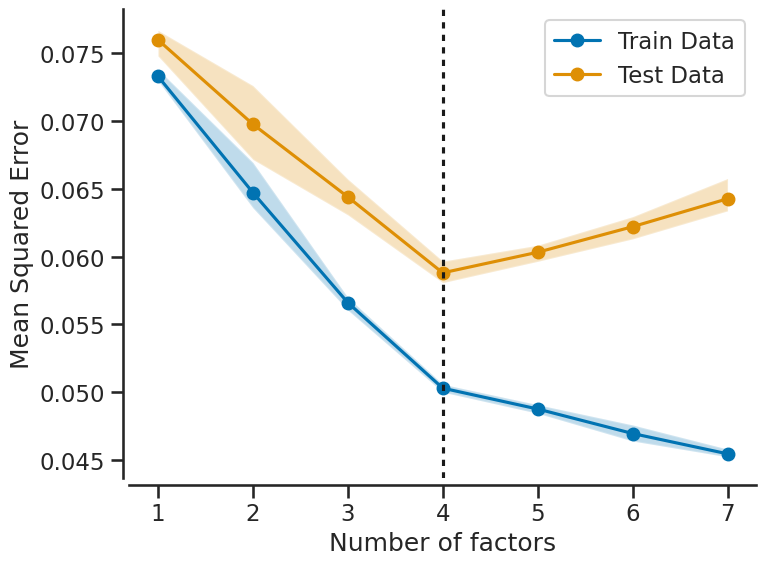

In [5]:
fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

inflection = (groups["MSE"]["mean"]["Test"] > groups["MSE"]["mean"]["Test"].shift()).idxmax() - 1

ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

## Trying on Our Data

In [6]:
from nnls import nnlsm_blockpivot as nnlstsq

def censored_nnlstsq2(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n in range(B.shape[1]):
        try:
            X[n] = nnlstsq(T[n], rhs[n], is_input_prod=True)[0].T
        except np.linalg.LinAlgError:
            X[n] = np.zeros((A.shape[1],))

    return X.T

def cv_nmf2(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    This code was adapted from Alex Williams at Stanford (https://bit.ly/2KDqKoW).

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence - the solution has converged when
                        the MSE of subsequent iterations are less than this number
    verbose (bool)    : if True, print out debugging information
    max_itr (int)     : the maximum number of iterations for convergence

    Returns
    -------
    U (ndarray)       :
    Vt (ndarray)      :
    train_err (float) :
    test_err (float)  :
    converged (bool)  :

    """
    # create the masking matrix to decide which values to "hold out"

    if M is None:
        M = np.random.rand(*data.shape) > p_holdout
        min_valid = rank + 1

        # check to make sure there are enough values in each row to avoid singular matrix issues
        # iterate over each row, and if the row contains less True values than rank
            # turn that row to all True values

        for i in range(M.shape[0]):
            if M[i].sum() < min_valid:
                needed = min_valid - M[i].sum()
                zero_indices = np.where(~M[i])[0]
                if len(zero_indices) >= needed:
                    M[i, np.random.choice(zero_indices, size=int(needed), replace=False)] = True

        for j in range(M.shape[1]):
            if M[:, j].sum() < min_valid:
                needed = min_valid - M[:, j].sum()
                zero_indices = np.where(~M[:, j])[0]
                if len(zero_indices) >= needed:
                    M[np.random.choice(zero_indices, size=int(needed), replace=False), j] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq2(U, data, M)
        U = censored_nnlstsq2(Vt.T, data.T, M.T).T

        # calculate the current iterations mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged

In [7]:
#importing data from Modulair MOD-00689
df = pd.read_csv('MOD-00689.csv')
df.head()

,timestamp,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T23:59:05Z,577612306,2025-12-31T18:59:05Z,MOD-00689,49.6,0.5,6.743,0.692,0.187,0.038,...,29.938,38.903,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,0.90
1,2025-12-31T23:58:05Z,577610344,2025-12-31T18:58:05Z,MOD-00689,49.7,0.5,7.506,0.821,0.251,0.027,...,29.223,39.248,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,0.97
2,2025-12-31T23:57:05Z,577610343,2025-12-31T18:57:05Z,MOD-00689,49.8,0.4,7.911,0.835,0.231,0.051,...,29.449,39.248,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,1.61
3,2025-12-31T23:56:05Z,577610342,2025-12-31T18:56:05Z,MOD-00689,50.0,0.4,7.611,0.901,0.256,0.050,...,29.677,38.185,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,1.54
4,2025-12-31T23:55:05Z,577610341,2025-12-31T18:55:05Z,MOD-00689,49.9,0.4,8.115,0.936,0.324,0.078,...,30.155,38.190,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,1.50


In [ ]:
#only including columns of interest and non na rows
COLS_TO_INCLUDE = ['timestamp_local','co', 'no2', 'o3', 'no', 'bin0', 'bin1', 'bin2','bin3','bin4','bin5']
df = df[COLS_TO_INCLUDE]
df.dropna()
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-06-02T19:59:38Z,265.418,38.885,41.858,4.566,3.029,0.201,0.077,0.034,0.047,0.030
1,2025-06-02T19:58:38Z,265.489,40.073,43.013,4.529,3.078,0.240,0.067,0.009,0.018,0.035
2,2025-06-02T19:57:38Z,270.415,38.178,42.160,4.550,3.182,0.204,0.079,0.026,0.040,0.013
3,2025-06-02T19:56:38Z,271.826,38.900,42.746,4.541,2.921,0.279,0.100,0.008,0.046,0.017
4,2025-06-02T19:55:38Z,266.900,38.190,42.462,4.544,2.925,0.274,0.087,0.013,0.018,0.026


In [8]:
#converting to datetime
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
df.head()

,timestamp,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T23:59:05Z,577612306,2025-12-31 18:59:05,MOD-00689,49.6,0.5,6.743,0.692,0.187,0.038,...,29.938,38.903,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,0.90
1,2025-12-31T23:58:05Z,577610344,2025-12-31 18:58:05,MOD-00689,49.7,0.5,7.506,0.821,0.251,0.027,...,29.223,39.248,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,0.97
2,2025-12-31T23:57:05Z,577610343,2025-12-31 18:57:05,MOD-00689,49.8,0.4,7.911,0.835,0.231,0.051,...,29.449,39.248,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,1.61
3,2025-12-31T23:56:05Z,577610342,2025-12-31 18:56:05,MOD-00689,50.0,0.4,7.611,0.901,0.256,0.050,...,29.677,38.185,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,1.54
4,2025-12-31T23:55:05Z,577610341,2025-12-31 18:55:05,MOD-00689,49.9,0.4,8.115,0.936,0.324,0.078,...,30.155,38.190,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,1.50


In [9]:
#taking hourly average of df. round to floor of the hour
df = df.groupby(df['timestamp_local'].dt.floor('h')).agg(co = ('co','mean'),
                                                         no2 = ('no2','mean'),
                                                         o3 = ('o3','mean'),
                                                         no = ('no','mean'),
                                                         bin0 = ('bin0','mean'),
                                                         bin1 = ('bin1','mean'),
                                                         bin2 = ('bin2','mean'),
                                                         bin3 = ('bin3','mean'),
                                                         bin4 = ('bin4','mean'),
                                                         bin5 = ('bin5','mean')).reset_index()

df = df.round(decimals = 2)
df = df.dropna()

In [10]:
df.to_csv('MOD-00689_timeseries_hourly.csv')

In [11]:
df = df.sample(frac=0.2)
df = df.set_index('timestamp_local')

def maximum_absolute_scaling(df):
    # copy the dataframe
    df_scaled = df.copy()
    # apply maximum absolute scaling
    for column in df_scaled.columns:
        df_scaled[column] = df_scaled[column]  / df_scaled[column].abs().max()
    return df_scaled

# call the maximum_absolute_scaling function
df_scaled = maximum_absolute_scaling(df)

df_scaled.head(10)

,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
timestamp_local,,,,,,,,,,
2025-09-03 07:00:00,0.095008,0.582140,0.477952,0.027926,0.117572,0.023150,0.023585,0.037234,0.067073,0.112245
2025-10-18 00:00:00,0.101122,0.645232,0.518146,0.028223,0.039561,0.014055,0.012972,0.010638,0.018293,0.020408
2025-06-21 12:00:00,0.077539,0.155059,0.815226,0.041592,0.142676,0.019016,0.012972,0.010638,0.018293,0.030612
2025-10-29 14:00:00,0.092227,0.541373,0.472869,0.034759,0.036225,0.016122,0.022406,0.026596,0.048780,0.051020
2025-04-23 08:00:00,0.092318,0.262072,0.742641,0.031788,0.045440,0.008268,0.008255,0.010638,0.018293,0.020408
2025-06-23 23:00:00,0.149272,0.121815,0.554675,0.030006,0.533524,0.087226,0.083726,0.111702,0.195122,0.265306
2025-06-16 04:00:00,0.098447,0.527299,0.510817,0.027778,0.334922,0.108309,0.055425,0.042553,0.054878,0.081633
2025-05-02 23:00:00,0.174684,0.778937,0.435867,0.030897,0.302828,0.124018,0.167453,0.255319,0.414634,0.551020
2025-08-19 21:00:00,0.095313,0.175928,0.559522,0.035651,0.028440,0.014469,0.017689,0.021277,0.036585,0.061224


In [24]:
replicates = 10

ranks = np.arange(1, 7)

frame = pd.DataFrame()

# fit the models
for rnk, j in itertools.product(ranks, range(replicates)):
    print ("Rank {}.{}".format(rnk, j))

    tr, te, converged = cv_nmf2(df_scaled.values, rnk, verbose=True, tol=1e-4, max_iter=150, p_holdout=0.2)[2:]

    if not converged:
        print ("there was a convergence issue: {}".format(rnk))

    else:
        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train", "Converged": converged},
            {"Rank": rnk, "MSE": te, "Group": "Test", "Converged": converged}])

        frame = pd.concat([frame, new_rows], ignore_index=True)

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

Rank 1.0
	Iter 3 = 0.00001
	Train/Test = 79.84/20.16
Rank 1.1
	Iter 2 = -0.00004
	Train/Test = 79.96/20.04
Rank 1.2
	Iter 2 = 0.00008
	Train/Test = 79.58/20.42
Rank 1.3
	Iter 3 = 0.00002
	Train/Test = 79.55/20.45
Rank 1.4
	Iter 2 = 0.00004
	Train/Test = 80.07/19.93
Rank 1.5
	Iter 2 = 0.00007
	Train/Test = 79.74/20.26
Rank 1.6
	Iter 3 = 0.00002
	Train/Test = 79.45/20.55
Rank 1.7
	Iter 2 = -0.00002
	Train/Test = 80.52/19.48
Rank 1.8
	Iter 3 = 0.00001
	Train/Test = 79.78/20.22
Rank 1.9
	Iter 2 = -0.00006
	Train/Test = 79.83/20.17
Rank 2.0
	Iter 2 = 0.00002
	Train/Test = 80.38/19.62
Rank 2.1
	Iter 150 = -0.00022
	Train/Test = 79.20/20.80
there was a convergence issue: 2
Rank 2.2
	Iter 4 = 0.00008
	Train/Test = 79.37/20.63
Rank 2.3
	Iter 150 = -0.00018
	Train/Test = 80.31/19.69
there was a convergence issue: 2
Rank 2.4
	Iter 8 = 0.00005
	Train/Test = 79.90/20.10
Rank 2.5
	Iter 150 = -0.00170
	Train/Test = 80.09/19.91
there was a convergence issue: 2
Rank 2.6
	Iter 51 = 0.00009
	Train/Test =

In [25]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.024260  0.001942  0.020808  0.021808  0.023882  0.027057   
      2      7.0  0.066729  0.098697  0.018213  0.018772  0.027637  0.217126   
      3     10.0  0.109083  0.128114  0.023045  0.023751  0.061932  0.346129   
      4      9.0  0.037693  0.033275  0.014195  0.014477  0.025869  0.097051   
      5      4.0  0.072786  0.109851  0.012379  0.013419  0.020657  0.205133   
      6     10.0  0.019929  0.005026  0.014573  0.014774  0.019749  0.027323   
Train 1     10.0  0.009340  0.000207  0.008887  0.009024  0.009387  0.009596   
      2      7.0  0.005439  0.000667  0.004772  0.004866  0.005270  0.006438   
      3     10.0  0.002357  0.000441  0.002066  0.002072  0.002127  0.003121   
      4      9.0  0.001059  0.000619  0.000479  0.000513  0.000802  0.002128   
      5      4.0  0.000596  0.000249  0.000226  0.000293  0.000704  0.000749   
      6     10.0  0.000702  0.000314  0.000297  0.000300  0.000669  0.001088   

                      
                 max  
Group Rank            
Test  1     0.027959  
      2     0.289166  
      3     0.410632  
      4     0.108528  
      5     0.237450  
      6     0.030505  
Train 1     0.009663  
      2     0.006865  
      3     0.003460  
      4     0.002284  
      5     0.000751  
      6     0.001139

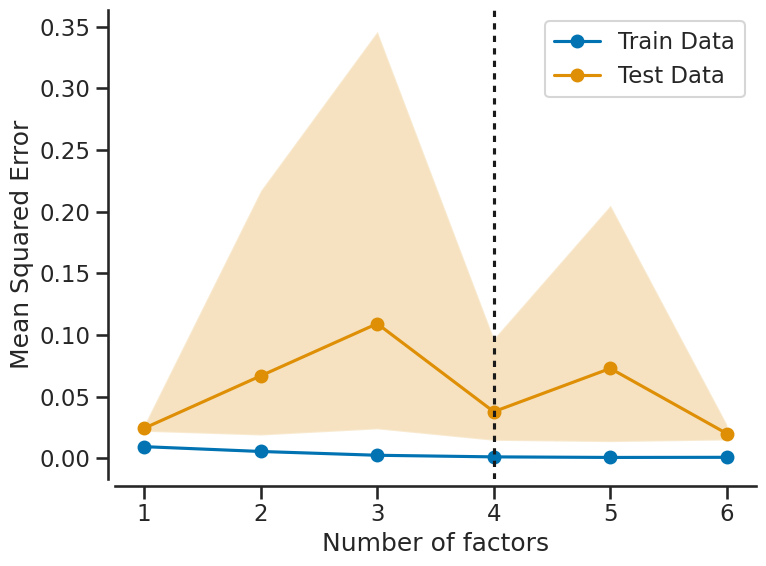

In [26]:
from scipy.signal import argrelextrema

fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

test_mse = groups["MSE"]["mean"]["Test"].values
ranks = groups["MSE"]["mean"]["Test"].index.values

local_min_idx = argrelextrema(test_mse, np.less)[0]

if len(local_min_idx) > 0:
    inflection = ranks[local_min_idx[0]]
    ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

N_FACTORS = 4

#####